In [50]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from transformers import BertTokenizer, BertModel
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import umap
import seaborn as sns
from matplotlib.patches import Ellipse

In [32]:
df = pd.read_csv('train/expanded_full_v2.csv')

# === BERT ===

# PCA

In [22]:
embeddings = np.load('train/bert_embeddings_expanded_full.npy')

In [23]:
pca = PCA(n_components=2, random_state=42)
downsized_embeddings = pca.fit_transform(embeddings)

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(embeddings)

GaussianMixture(n_components=2, random_state=42)

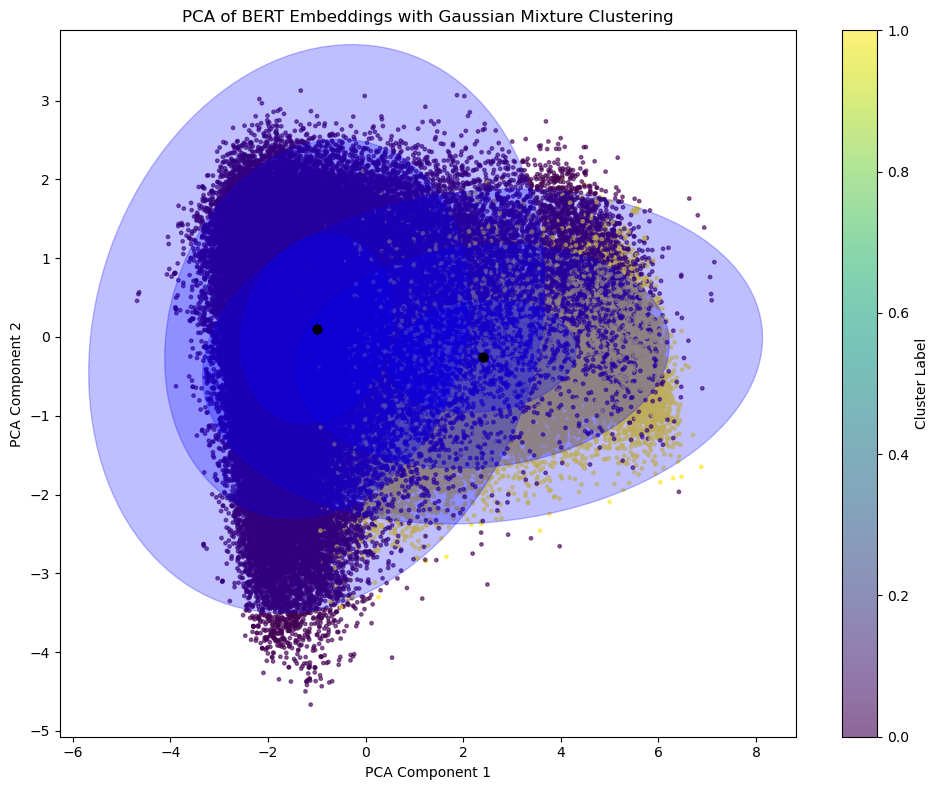

In [ ]:
def project_gaussian(mean, cov, pca):
    mean_2d = pca.transform(mean.reshape(1, -1))[0]
    W = pca.components_
    cov_2d = W @ cov @ W.T
    return mean_2d, cov_2d

def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, _ = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
        for nsig in range(1, 4):
            ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                     angle=angle, alpha=0.25, **kwargs))
            ax.plot(position[0], position[1], marker="o", markersize=6,
                    color="k", lw=0)

plt.figure(figsize=(10, 8))
ax = plt.gca()
scatter = ax.scatter(downsized_embeddings[:, 0],
                     downsized_embeddings[:, 1],
                     c=gmm.predict(embeddings), cmap='viridis', s=6, alpha=0.6)

for mean, cov in zip(gmm.means_, gmm.covariances_):
    m2d, c2d = project_gaussian(mean, cov, pca)
    draw_ellipse(m2d, c2d, ax=ax, color='blue')

plt.title("PCA of BERT Embeddings with Gaussian Mixture Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.tight_layout()
plt.show()

# UMAP

In [3]:
scaled_embeddings = StandardScaler().fit_transform(embeddings)

In [16]:
umap_model = umap.UMAP(metric="cosine", n_neighbors=15, min_dist=0.3, random_state=42)
umap_2d = umap_model.fit_transform(scaled_embeddings)

/opt/anaconda3/envs/diss/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/diss/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


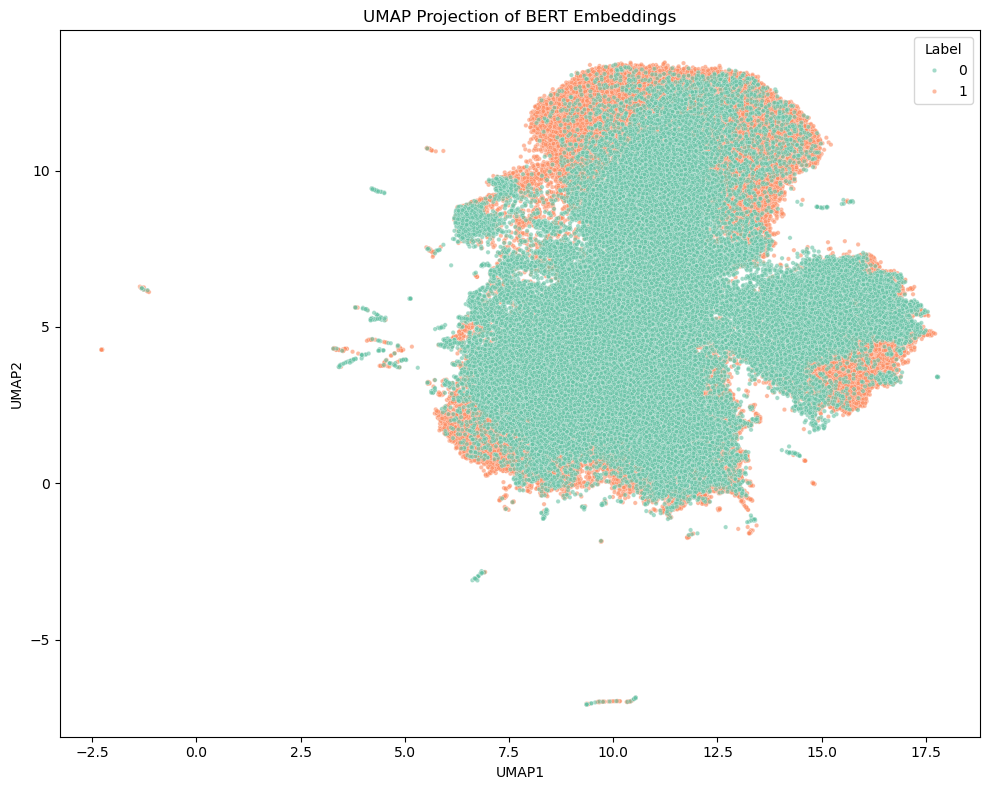

In [17]:
df_umap = pd.DataFrame(umap_2d, columns=["UMAP1", "UMAP2"])
df_umap["label"] = df["label"].values
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="label", palette="Set2", s=10, alpha=0.6)
plt.title("UMAP Projection of BERT Embeddings")
plt.legend(title="Label", loc="best")
plt.tight_layout()
plt.show()

# === Sentence Transformer ===

# PCA

In [4]:
sf_embeddings = np.load('train/SF_embeddings_expanded_full.npy')

In [8]:
model = GaussianMixture(n_components=2, random_state=42)
model.fit(sf_embeddings)
pca = PCA(n_components=2, random_state=42)

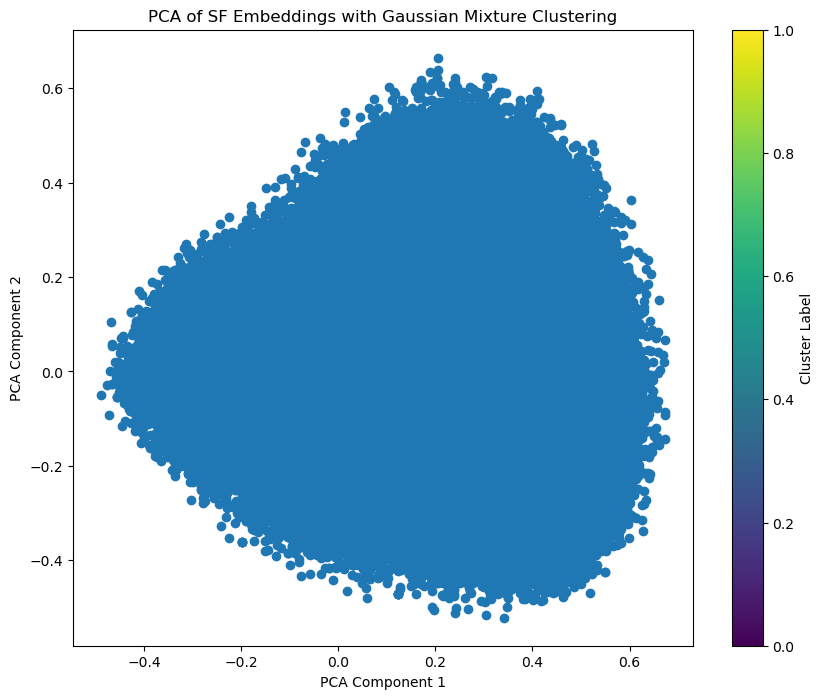

In [10]:
downsized_sf_embeddings = pca.fit_transform(sf_embeddings)
plt.figure(figsize=(10, 8))
plt.scatter(downsized_sf_embeddings[:, 0], downsized_sf_embeddings[:, 1])
plt.title('PCA of SF Embeddings with Gaussian Mixture Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# UMAP

/opt/anaconda3/envs/diss/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/diss/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


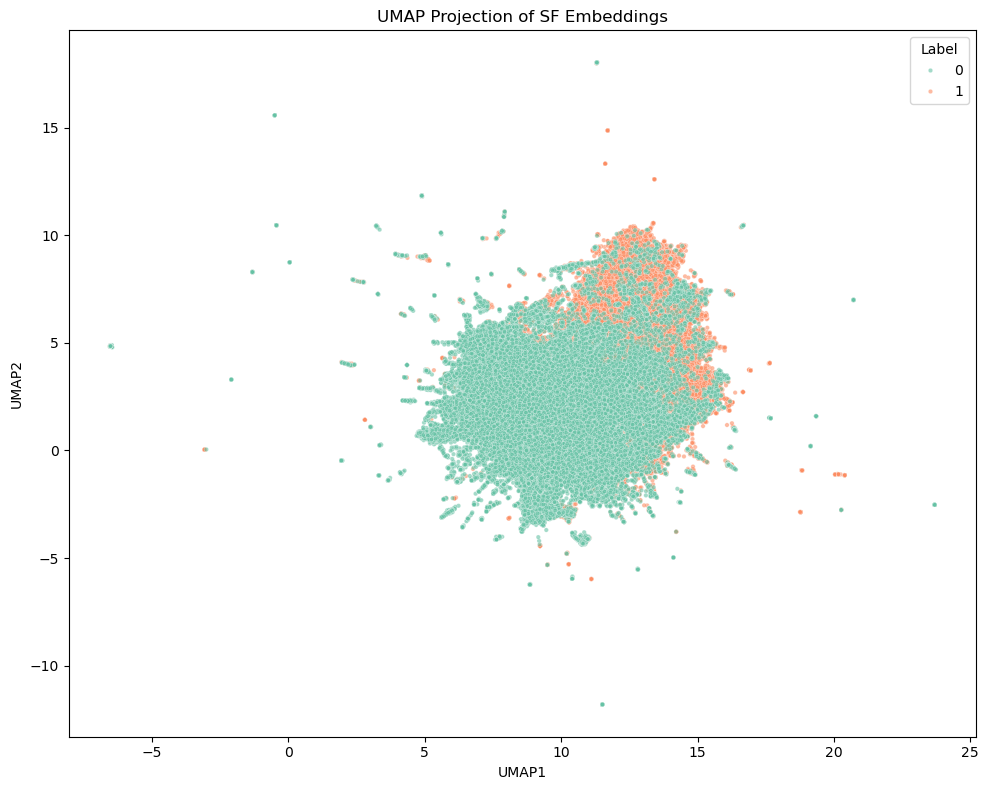

In [14]:
sf_scaled_embeddings = StandardScaler().fit_transform(sf_embeddings)
umap_model_sf = umap.UMAP(metric="cosine", random_state=42)
umap_2d_sf = umap_model_sf.fit_transform(sf_scaled_embeddings)
df_umap_sf = pd.DataFrame(umap_2d_sf, columns=["UMAP1", "UMAP2"])
df_umap_sf["label"] = df["label"].values
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap_sf, x="UMAP1", y="UMAP2", hue="label", palette="Set2", s=10, alpha=0.6)
plt.title("UMAP Projection of SF Embeddings")
plt.legend(title="Label", loc="best")
plt.tight_layout()
plt.show()

# Data V2

In [ ]:
embeddings = np.load('train/bert_embeddings_expanded_full_v2.npy')
pca = PCA(n_components=2, random_state=42)
downsized_embeddings_v2 = pca.fit_transform(embeddings)
gmm_v2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_v2.fit(embeddings)

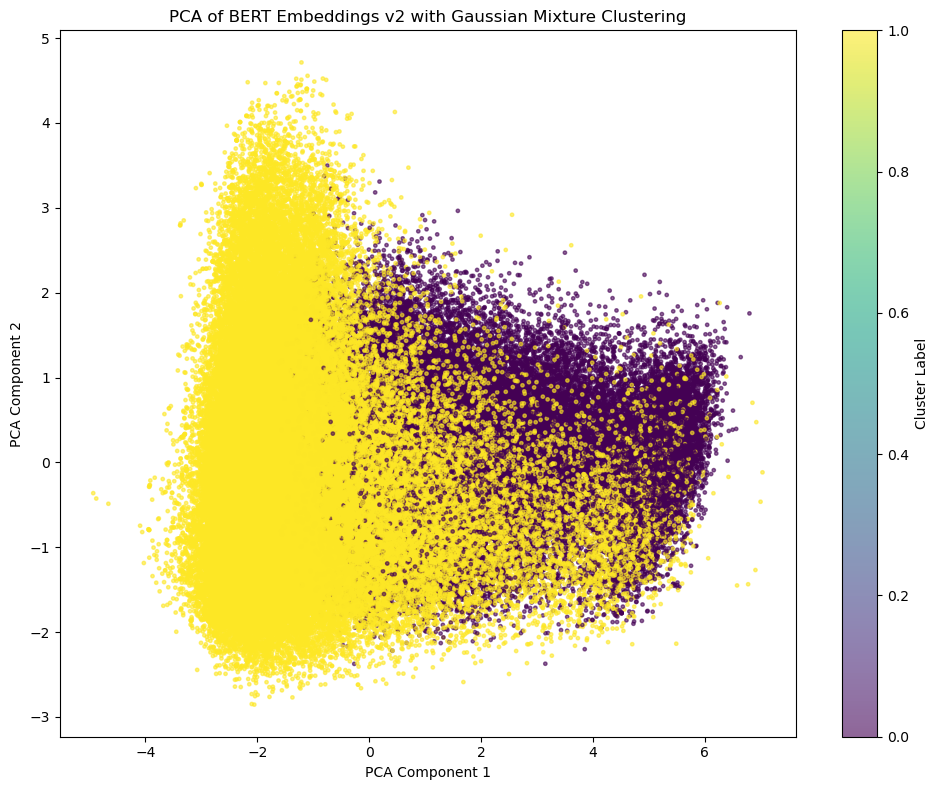

In [ ]:
def project_gaussian_v2(mean, cov, pca):
    mean_2d = pca.transform(mean.reshape(1, -1))[0]
    W = pca.components_
    cov_2d = W @ cov @ W.T
    return mean_2d, cov_2d
def draw_ellipse_v2(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, _ = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
        for nsig in range(1, 4):
            ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                     angle=angle, alpha=0.25, **kwargs))
            ax.plot(position[0], position[1], marker="o", markersize=6,
                    color="k", lw=0)
plt.figure(figsize=(10, 8))
ax = plt.gca()
scatter_v2 = ax.scatter(downsized_embeddings_v2[:, 0],
                         downsized_embeddings_v2[:, 1],
                         c=gmm_v2.predict(embeddings), cmap='viridis', s=6, alpha=0.6)
for mean, cov in zip(gmm_v2.means_, gmm_v2.covariances_):
    m2d_v2, c2d_v2 = project_gaussian_v2(mean, cov, pca)
    draw_ellipse_v2(m2d_v2, c2d_v2, ax=ax, color='blue')
plt.title("PCA of BERT Embeddings v2 with Gaussian Mixture Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter_v2, label="Cluster Label")
plt.tight_layout()
plt.show()

In [57]:
df = pd.read_csv('train/expanded_full_v2.csv')

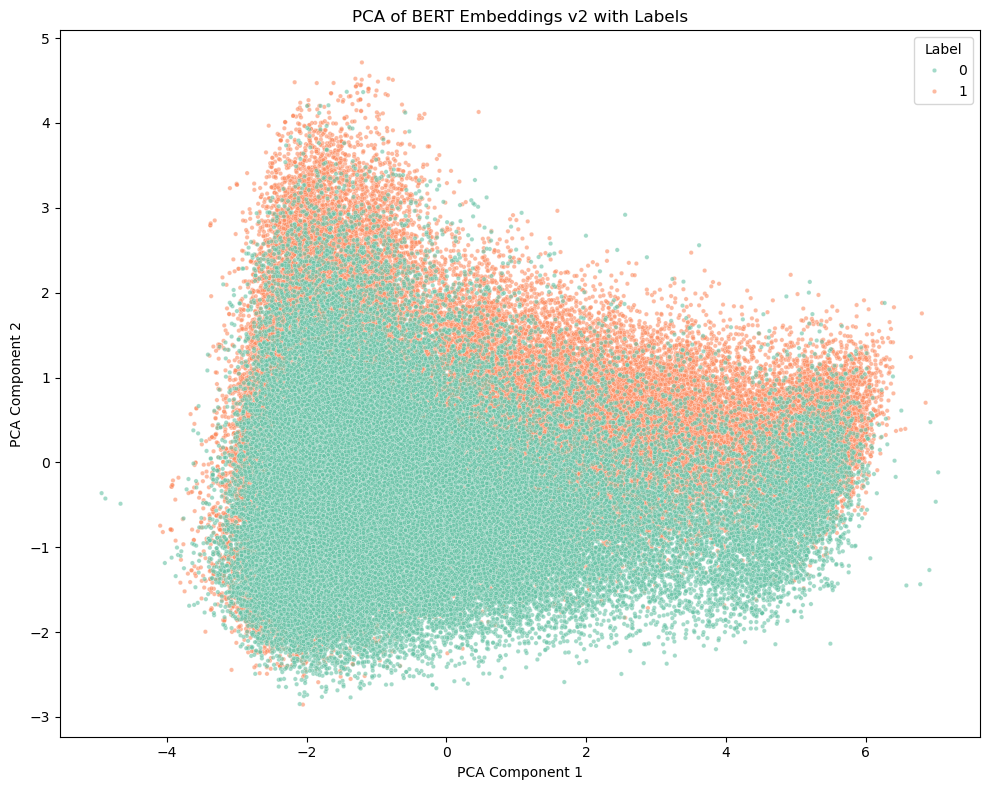

In [58]:
# Plot downsized_embeddings with the labels in df
plt.figure(figsize=(10, 8))
sns.scatterplot(x=downsized_embeddings_v2[:, 0], y=downsized_embeddings_v2[:, 1],
                hue=df['label'], palette='Set2', s=10, alpha=0.6)
plt.title("PCA of BERT Embeddings v2 with Labels")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Label", loc="best")
plt.tight_layout()
plt.show()